In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, sys, json

sns.set_palette("muted")
sns.set_context("talk")
sns.set_style("white")
pd.set_option("display.max_columns", None)

plt.rcParams['font.family']='NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

In /opt/conda/lib/python3.7/site-packages/matplotlib/mpl-data/stylelib/_classic_test.mplstyle: 
The text.latex.preview rcparam was deprecated in Matplotlib 3.3 and will be removed two minor releases later.
In /opt/conda/lib/python3.7/site-packages/matplotlib/mpl-data/stylelib/_classic_test.mplstyle: 
The mathtext.fallback_to_cm rcparam was deprecated in Matplotlib 3.3 and will be removed two minor releases later.
In /opt/conda/lib/python3.7/site-packages/matplotlib/mpl-data/stylelib/_classic_test.mplstyle: Support for setting the 'mathtext.fallback_to_cm' rcParam is deprecated since 3.3 and will be removed two minor releases later; use 'mathtext.fallback : 'cm' instead.
In /opt/conda/lib/python3.7/site-packages/matplotlib/mpl-data/stylelib/_classic_test.mplstyle: 
The validate_bool_maybe_none function was deprecated in Matplotlib 3.3 and will be removed two minor releases later.
In /opt/conda/lib/python3.7/site-packages/matplotlib/mpl-data/stylelib/_classic_test.mplstyle: 
The savefig.

### create rectangle

In [58]:
import geopandas as gpd
from shapely.geometry import MultiPoint

def create_rec(x, y, width, length, angle):
    l_half = length/2
    w_half = width/2
    a_rad = np.deg2rad(angle)
    
    def get_coord(l_half, w_half, a_rad):
        X = x + l_half * np.sin(a_rad) - w_half * np.cos(a_rad)
        Y = y + l_half * np.cos(a_rad) + w_half * np.sin(a_rad)
        return (X, Y)
    
    points = [get_coord(l_half, w_half, a_rad),
              get_coord(-l_half, w_half, a_rad),
              get_coord(-l_half, -w_half, a_rad),
              get_coord(l_half, -w_half, a_rad)
             ]
    
    rec = gpd.GeoDataFrame({"points":[points], "geometry":[MultiPoint(points).convex_hull]})
    return rec

In [59]:
rec = create_rec(0, 0, 30, 10, 15)
rec

,points,geometry
0,"[(-13.194792168823422, 8.711914807983153), (-1...","POLYGON ((13.19479 -8.71191, -15.78298 -0.9473..."


<AxesSubplot:>

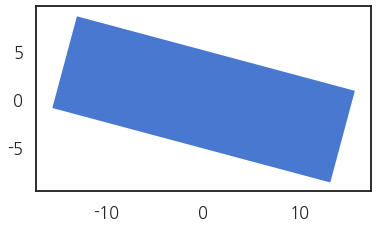

In [60]:
rec.plot()

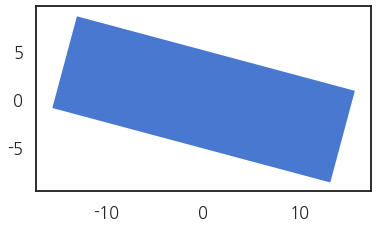

In [61]:
fig, ax = plt.subplots()
rec.plot(ax=ax)
fig.savefig("5_shadow_2.png")

### diurnal motion of the sun

In [17]:
import datetime
from pysolar.solar import get_altitude, get_azimuth

# Daejeon
lats = list(range(0, 100, 10))
lon = 127.3845

# Spring equinox
KST = datetime.timezone(datetime.timedelta(hours=9))
date = datetime.datetime(2017, 3, 21, 13, 0, 0, tzinfo=KST)

# data
nlats = len(lats)
alts_lat = {}
azis_lat = {}
date_hr_lat = {}

# altitudes and azimuthal angles
for i, lat in enumerate(lats):
    alts, azis, dates_hr = [], [], []
    for hh in range(24):
        for mm in range(0, 60, 1):
            date_hr = datetime.datetime(2017, 3, 21, hh, mm, 0, tzinfo=KST)
            dates_hr.append(date_hr)
            alt = get_altitude(lat, lon, date_hr)
            azi = get_azimuth(lat, lon, date_hr)
            alts.append(alt)
            azis.append(azi)

    date_hr_lat[i] = dates_hr
    alts = np.array(alts)      
    alts_lat[i] = alts
    azis = np.array(azis)
    azis_lat[i] = azis

hhmm = list(range(1440))    

In [18]:
df_azialt = {}
select_values = np.linspace(90, 270+11.25, 18)
azis_arcgis = {}
alts_arcgis = {}

for i, lat in enumerate(lats):
    df_azialt[i] = pd.DataFrame({"date_hr":hhmm, "azimuth":azis_lat[i], "altitude":alts_lat[i]})
    pcut = pd.cut(df_azialt[i]["azimuth"], select_values)
    azis_arcgis[i] = df_azialt[i]["azimuth"].groupby(pcut).nth(0).values
    alts_arcgis[i] = df_azialt[i]["altitude"].groupby(pcut).nth(0).values

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:19: UserWarning: FixedFormatter should only be used together with FixedLocator
/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


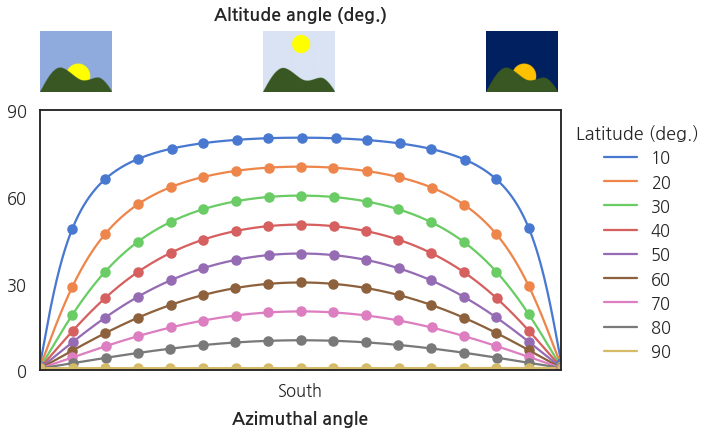

In [57]:
from matplotlib.ticker import MultipleLocator

fig, ax = plt.subplots(figsize=(10, 10))
lines = []

for i in range(1, nlats):
    line = ax.plot(azis_lat[i], alts_lat[i], zorder=1)
    lines.append(line)
    ax.scatter(azis_arcgis[i], alts_arcgis[i], zorder=1.1)
    
ax.set_aspect("equal")
ax.set_xlim(90, 270)  
ax.set_ylim(0, 90)

xticklabels = [""]*len(ax.get_xticks())
xticklabels[0] = "East"
xticklabels[int(len(ax.get_xticks())/2)] = "South"
xticklabels[-1] = "West"
ax.set_xticklabels(xticklabels)
ax.set_xlabel("Azimuthal angle", fontdict={"fontweight":"bold"}, labelpad=12)
ax.set_title("Altitude angle (deg.)", fontdict={"fontweight":"bold"}, pad=90)
ax.yaxis.set_major_locator(MultipleLocator(30))

plt.legend(lats[1:], bbox_to_anchor=(1,1), frameon=False, title="Latitude (deg.)")

im_sunrise = plt.imread("sunrise.png")
ax_sunrise = fig.add_axes([0.06, 0.69, 0.1, 0.1], anchor="NW", zorder=2)
ax_sunrise.imshow(im_sunrise)
ax_sunrise.axis("off")

im_suntop = plt.imread("suntop.png")
ax_suntop = fig.add_axes([0.37, 0.69, 0.1, 0.1], anchor="NW", zorder=2)
ax_suntop.imshow(im_suntop)
ax_suntop.axis("off")


im_sunset = plt.imread("sunset.png")
ax_sunset = fig.add_axes([0.68, 0.69, 0.1, 0.1], anchor="NW", zorder=2)
ax_sunset.imshow(im_sunset)
ax_sunset.axis("off")

fig.tight_layout()
fig.savefig("5_shadow_3.png")

### create shadow

In [ ]:
def create_shadow_1(lat, src_x, src_y, src_width, src_)

In [14]:
alts = np.load("alts_arcgis.npy")
azis = np.load("azis_arcgis.npy")

In [10]:
def A(H, lat):
    return np.rad2deg(np.arcsin(np.cos(np.deg2rad(lat))*np.cos(np.pi - np.deg2rad(Hs))))

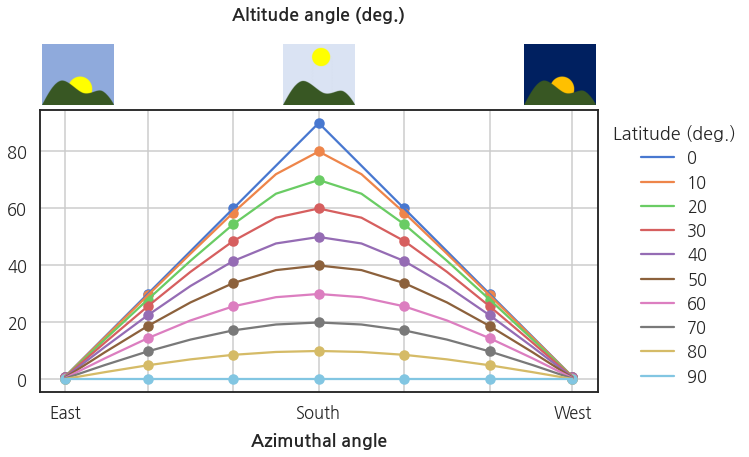

In [13]:
Hs = np.linspace(90, 270, 25)
Hs[0] += 1
Hs[-1] -= 1

fig, ax = plt.subplots(figsize=(10,10))
lines = []
for lat in range(0, 100, 10):
    if lat >= 0:
        Hs = np.linspace(90, 270, 13)
        sign = 1
    else:
        Hs = np.linspace(270, 450, 13)
        sign = -1
    Hs[0] += 1
    Hs[-1] -= 1
    As = sign * np.rad2deg(np.arcsin(np.cos(np.deg2rad(lat))*np.cos(np.pi - np.deg2rad(Hs))))
    
    ax.scatter([H for i, H in enumerate(Hs) if i%2 == 0], [A for i, A in enumerate(As) if i%2 == 0])
    line = ax.plot(Hs, As)
    lines.append(line)

ax.set_aspect("equal")
ax.grid()
ax.set_xticks([H for i, H in enumerate(Hs) if i%2 == 0])
xticklabels = [""]*len(ax.get_xticks())
xticklabels[0] = "East"
xticklabels[int(len(ax.get_xticks())/2)] = "South"
xticklabels[-1] = "West"
ax.set_xticklabels(xticklabels)
ax.set_xlabel("Azimuthal angle", fontdict={"fontweight":"bold"}, labelpad=12)
ax.set_title("Altitude angle (deg.)", fontdict={"fontweight":"bold"}, pad=90)

plt.legend(list(range(0, 100, 10)), bbox_to_anchor=(1,1), frameon=False, title="Latitude (deg.)")

im_sunrise = plt.imread("sunrise.png")
ax_sunrise = fig.add_axes([0.128, 0.69, 0.1, 0.1], anchor="NW", zorder=2)
ax_sunrise.imshow(im_sunrise)
ax_sunrise.axis("off")

im_suntop = plt.imread("suntop.png")
ax_suntop = fig.add_axes([0.463, 0.69, 0.1, 0.1], anchor="NW", zorder=2)
ax_suntop.imshow(im_suntop)
ax_suntop.axis("off")


im_sunset = plt.imread("sunset.png")
ax_sunset = fig.add_axes([0.798, 0.69, 0.1, 0.1], anchor="NW", zorder=2)
ax_sunset.imshow(im_sunset)
ax_sunset.axis("off")

plt.show()

### create shadow